## 01: Import Libraries
We import all tools needed for model evaluation.
- pandas and numpy: for data handling
- sklearn: for confusion matrix, ROC curve, and metrics
- matplotlib and seaborn: for plotting results

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, roc_curve, auc, 
                               precision_score, recall_score, f1_score, accuracy_score)
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported")

All libraries imported


## 02: Load Saved Predictions from Random Forest
We load the test labels, predictions, and prediction
probabilities that we saved on Day 6 when training
Random Forest. We need these to build the confusion
matrix and ROC curve.

In [3]:
SAVE_PATH = r"C:\Users\EmaSk\Desktop\sleep-apnea-detection\eman"

y_test = np.load(f"{SAVE_PATH}\\rf_y_test.npy")
y_pred_rf = np.load(f"{SAVE_PATH}\\rf_y_pred.npy")
y_pred_proba_rf = np.load(f"{SAVE_PATH}\\rf_y_pred_proba.npy")

print(f"Random Forest results loaded")
print(f"y_test shape          : {y_test.shape}")
print(f"y_pred_rf shape       : {y_pred_rf.shape}")
print(f"y_pred_proba_rf shape : {y_pred_proba_rf.shape}")

Random Forest results loaded
y_test shape          : (551,)
y_pred_rf shape       : (551,)
y_pred_proba_rf shape : (551,)


## 03: Plot Confusion Matrix for Random Forest
A confusion matrix shows exactly how many predictions were
correct and incorrect for each class.
- True Negative: correctly predicted Normal
- True Positive: correctly predicted Apnea
- False Positive: predicted Apnea but was Normal
- False Negative: predicted Normal but was actually Apnea
False Negatives are the most dangerous in medical diagnosis
because they mean we missed a real apnea event.

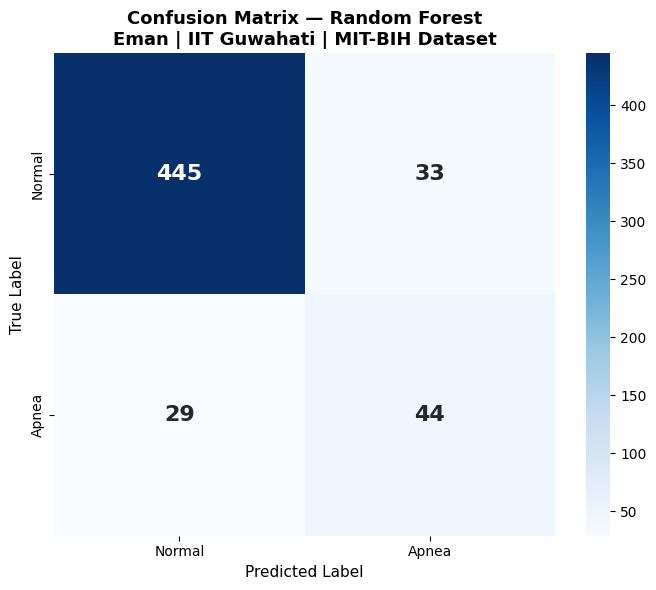

Confusion matrix plotted

True Negative (correct Normal) : 445
False Positive (wrong Apnea)    : 33
False Negative (missed Apnea)   : 29
True Positive (correct Apnea)   : 44


In [4]:
cm = confusion_matrix(y_test, y_pred_rf)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Apnea'],
            yticklabels=['Normal', 'Apnea'],
            cbar=True, annot_kws={'size': 16, 'weight': 'bold'}, ax=ax)

ax.set_title("Confusion Matrix — Random Forest\nEman | IIT Guwahati | MIT-BIH Dataset",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Predicted Label", fontsize=11)
ax.set_ylabel("True Label", fontsize=11)

plt.tight_layout()
plt.savefig(f"{SAVE_PATH}\\rf_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

print("Confusion matrix plotted")
print(f"\nTrue Negative (correct Normal) : {cm[0][0]}")
print(f"False Positive (wrong Apnea)    : {cm[0][1]}")
print(f"False Negative (missed Apnea)   : {cm[1][0]}")
print(f"True Positive (correct Apnea)   : {cm[1][1]}")

## 04: Plot ROC Curve for Random Forest
The ROC curve shows the tradeoff between True Positive Rate
(catching real apnea) and False Positive Rate (false alarms)
at different decision thresholds.
AUC (Area Under Curve) summarizes overall performance —
1.0 is perfect, 0.5 is random guessing.

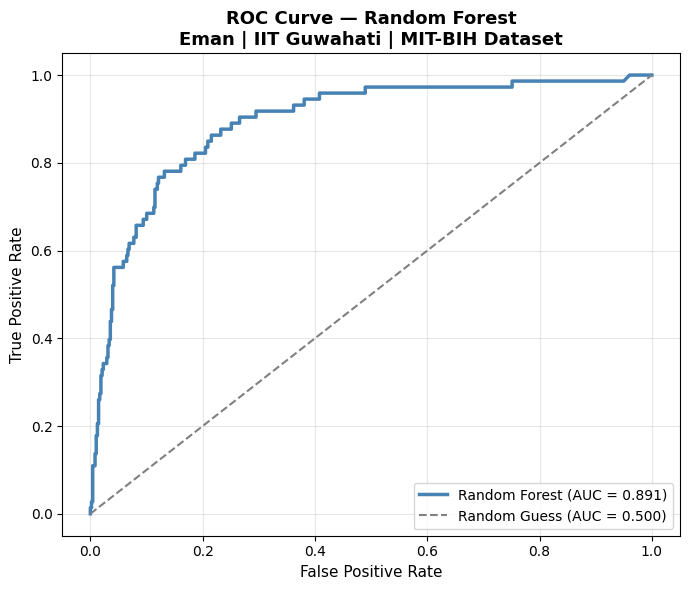

ROC curve plotted
AUC Score: 0.8914


In [5]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_rf)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='steelblue', linewidth=2.5, label=f'Random Forest (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guess (AUC = 0.500)')

ax.set_title("ROC Curve — Random Forest\nEman | IIT Guwahati | MIT-BIH Dataset",
             fontsize=13, fontweight='bold')
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{SAVE_PATH}\\rf_roc_curve.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"ROC curve plotted")
print(f"AUC Score: {roc_auc:.4f}")

## 05: Calculate Precision, Recall, F1-Score
We calculate the key evaluation metrics specifically for
the Apnea class since that's the class we care most about
detecting correctly in a medical context.

In [6]:
precision = precision_score(y_test, y_pred_rf)
recall = recall_score(y_test, y_pred_rf)
f1 = f1_score(y_test, y_pred_rf)
accuracy = accuracy_score(y_test, y_pred_rf)

print(f"Random Forest Metrics Summary:")
print(f"\nAccuracy  : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision : {precision:.4f} ({precision*100:.2f}%)  — of predicted apnea, how many were correct")
print(f"Recall    : {recall:.4f} ({recall*100:.2f}%)  — of actual apnea, how many were caught")
print(f"F1-Score  : {f1:.4f} ({f1*100:.2f}%)  — balance between precision and recall")
print(f"AUC       : {roc_auc:.4f} ({roc_auc*100:.2f}%)")

Random Forest Metrics Summary:

Accuracy  : 0.8875 (88.75%)
Precision : 0.5714 (57.14%)  — of predicted apnea, how many were correct
Recall    : 0.6027 (60.27%)  — of actual apnea, how many were caught
F1-Score  : 0.5867 (58.67%)  — balance between precision and recall
AUC       : 0.8914 (89.14%)


## 06: Ablation Study — Which Signals Matter Most?
An ablation study tests model performance using different
combinations of signals to measure exactly how much each
signal contributes to overall accuracy.
We test 7 combinations:
- ECG only, EEG only, Respiratory only
- ECG+EEG, ECG+Respiratory, EEG+Respiratory
- All 3 signals combined (our full model)
This directly answers our core research question:
does multi-modal fusion actually help?

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

df = pd.read_csv(f"{SAVE_PATH}\\merged_features.csv")

# Define feature groups
ecg_features = ['mean_rr', 'sdnn', 'rmssd', 'mean_hr', 'pnn50', 'lf_hf_ratio', 'cnn_prob']
eeg_features = ['delta_power', 'theta_power', 'alpha_power', 'beta_power', 
                 'rel_delta', 'rel_theta', 'rel_alpha', 'rel_beta', 'delta_beta_ratio']
resp_features = ['breathing_rate', 'mean_amplitude', 'std_amplitude', 'mean_peak_dist',
                  'breath_regularity', 'apnea_index', 'ie_ratio']

combinations = {
    'ECG only': ecg_features,
    'EEG only': eeg_features,
    'Respiratory only': resp_features,
    'ECG + EEG': ecg_features + eeg_features,
    'ECG + Respiratory': ecg_features + resp_features,
    'EEG + Respiratory': eeg_features + resp_features,
    'All 3 Signals (Full Model)': ecg_features + eeg_features + resp_features
}

results = []

for combo_name, features in combinations.items():
    X_combo = df[features]
    y_combo = df['label']
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_combo, y_combo, test_size=0.2, random_state=42, stratify=y_combo)
    
    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
    
    model = RandomForestClassifier(n_estimators=200, max_depth=15, 
                                     min_samples_split=5, random_state=42, n_jobs=-1)
    model.fit(X_train_smote, y_train_smote)
    
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    fpr_combo, tpr_combo, _ = roc_curve(y_test, y_pred_proba)
    auc_combo = auc(fpr_combo, tpr_combo)
    
    results.append({
        'Signal Combination': combo_name,
        'Num Features': len(features),
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'AUC': auc_combo
    })
    
    print(f" {combo_name:30s} | Acc: {acc:.4f} | F1: {f1:.4f} | AUC: {auc_combo:.4f}")

df_ablation = pd.DataFrame(results)
print(f"\n{'='*80}")
print("ABLATION STUDY COMPLETE!")
print(f"{'='*80}")

 ECG only                       | Acc: 0.8748 | F1: 0.5818 | AUC: 0.8791
 EEG only                       | Acc: 0.8022 | F1: 0.4410 | AUC: 0.7964
 Respiratory only               | Acc: 0.8512 | F1: 0.5119 | AUC: 0.8264
 ECG + EEG                      | Acc: 0.8639 | F1: 0.5399 | AUC: 0.8806
 ECG + Respiratory              | Acc: 0.8893 | F1: 0.6211 | AUC: 0.8784
 EEG + Respiratory              | Acc: 0.8820 | F1: 0.5695 | AUC: 0.8658
 All 3 Signals (Full Model)     | Acc: 0.8875 | F1: 0.5867 | AUC: 0.8914

ABLATION STUDY COMPLETE!


## 07: Visualize the Ablation Study Results
We plot a bar chart comparing all 7 signal combinations
across accuracy, F1-score, and AUC. This visually shows
which signals and combinations matter most for detecting
sleep apnea.

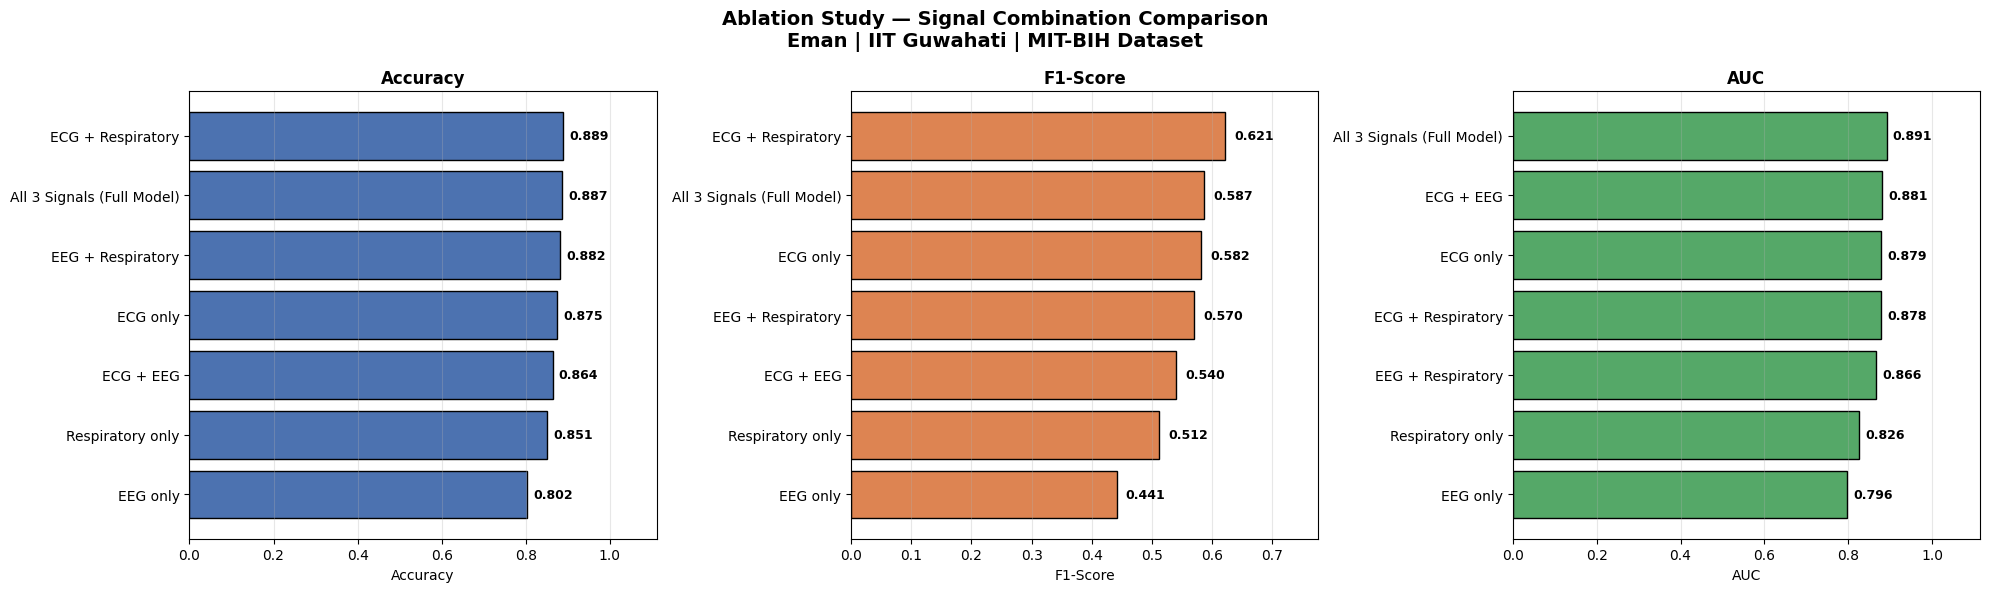

Ablation study plot saved


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Ablation Study — Signal Combination Comparison\nEman | IIT Guwahati | MIT-BIH Dataset",
             fontsize=14, fontweight='bold')

metrics_to_plot = ['Accuracy', 'F1-Score', 'AUC']
colors_list = ['#4C72B0', '#DD8452', '#55A868']

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx]
    sorted_df = df_ablation.sort_values(metric, ascending=True)
    bars = ax.barh(sorted_df['Signal Combination'], sorted_df[metric], 
                    color=colors_list[idx], edgecolor='black')
    ax.set_title(metric, fontweight='bold', fontsize=12)
    ax.set_xlabel(metric)
    ax.set_xlim(0, max(sorted_df[metric]) * 1.25)  # add space for labels
    ax.grid(True, alpha=0.3, axis='x')
    
    for bar, val in zip(bars, sorted_df[metric]):
        ax.text(val + 0.015, bar.get_y() + bar.get_height()/2, 
                f'{val:.3f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(f"{SAVE_PATH}\\ablation_study_plot.png", dpi=150, bbox_inches='tight')
plt.show()
print("Ablation study plot saved")

## 08: Save the Ablation Study Results
We save the complete ablation study table as a CSV file.
This table will be used directly in our IEEE report's
results section to support our core research finding.

In [13]:
df_ablation.to_csv(f"{SAVE_PATH}\\ablation_study_results.csv", index=False)

print(f"Ablation study results saved")
print(f"\n{df_ablation.to_string(index=False)}")

Ablation study results saved

        Signal Combination  Num Features  Accuracy  Precision   Recall  F1-Score      AUC
                  ECG only             7  0.874773   0.521739 0.657534  0.581818 0.879148
                  EEG only             9  0.802178   0.352459 0.589041  0.441026 0.796426
          Respiratory only             7  0.851180   0.452632 0.589041  0.511905 0.826360
                 ECG + EEG            16  0.863884   0.488889 0.602740  0.539877 0.880553
         ECG + Respiratory            14  0.889292   0.568182 0.684932  0.621118 0.878403
         EEG + Respiratory            16  0.882033   0.551282 0.589041  0.569536 0.865822
All 3 Signals (Full Model)            23  0.887477   0.571429 0.602740  0.586667 0.891371
